In [3]:
print("Hello, World!")

Hello, World!


## Libraries 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

## Loading the Dataset

In [5]:
df = pd.read_csv('Customer Data.csv')
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## Exploratory Data Analysis

In [6]:
df.shape

(8950, 18)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

** As CUST_ID is not necessary in our model building we can remove this column

In [8]:
df = df.drop(['CUST_ID'], axis=1)

In [9]:
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [10]:
df.isnull().sum()

BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

- As CREDIT_LIMIT has only one null value we can simply remove the record
- And for MINIMUM_PAYMENTS more than 300 records are there so we can impute it replacing with mean of the MINIMUM_PAYMENTS.


In [11]:
df.dropna(subset=["CREDIT_LIMIT"], inplace=True)
df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].mean())

df.isnull().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

- Checking if there are any duplicate rows in it or not

In [12]:
df.duplicated().sum()

np.int64(0)

## Data Distribution Analysis
Analyzing the distributions and spread of each numerical feature to assess skewness and identify potential outliers.

## Distribution Summary — Key Observations

### BALANCE
> **Meaning:** The amount of money a customer currently owes on their credit card (unpaid balance).
- Strongly **right-skewed** — the majority of customers maintain a **low balance** (close to zero), while a small subset carries very high unpaid balances.
- Presence of heavy outliers at the upper end suggests a group of **high-debt revolvers** who rely on credit heavily.

### BALANCE_FREQUENCY
> **Meaning:** How often the balance is updated — a score from 0 to 1 (1 = updated every month).
- Shows a clear **bimodal pattern** — most values cluster near **0 or 1**, indicating customers either update their balance almost every month (frequent users) or rarely at all (inactive users).
- Very few customers fall in the middle range, confirming a distinct behavioral divide.

### PURCHASES
> **Meaning:** Total amount spent on purchases made using the credit card.
- Strongly **right-skewed** with a large spike at **zero** — a significant portion of customers make **no purchases** at all.
- A long right tail shows a small group of high-spending customers, likely prime candidates for rewards or premium segments.

### ONEOFF_PURCHASES
> **Meaning:** Total amount spent on single large purchases (one-time transactions, not split into installments).
- Extremely **right-skewed** with the majority at **zero** — most customers do not make large one-off (single) purchases.
- The heavy tail represents occasional big spenders, possibly buying high-value items infrequently.

### INSTALLMENTS_PURCHASES
> **Meaning:** Total amount spent on purchases paid in installments (EMI / split payments).
- **Right-skewed** with a large zero-concentration — many customers avoid installment buying.
- A moderate tail suggests a segment that **prefers EMI-style purchases**, likely for larger goods.

### CASH_ADVANCE
> **Meaning:** Amount of cash withdrawn in advance using the credit card (like a short-term loan).
- Severely **right-skewed** with most customers at **zero** — the majority never take cash advances.
- Extreme outliers in the upper tail represent **high-risk customers** who routinely use the credit card as a cash source, incurring high fees.

### PURCHASES_FREQUENCY
> **Meaning:** How regularly purchases are made — a score from 0 to 1 (1 = purchases made every month).
- **Bimodal** — strong peaks at both **0** (never purchase) and **1** (purchase every month), with relatively few customers in between.
- This cleanly separates **active purchasers** from **inactive cardholders**.

### ONEOFF_PURCHASES_FREQUENCY
> **Meaning:** How often one-off (single large) purchases are made — a score from 0 to 1.
- **Right-skewed with a dominant zero peak** — most customers never make one-off purchases in a given month.
- A secondary bump near 1.0 indicates a small group of consistent single-purchase users.

### PURCHASES_INSTALLMENTS_FREQUENCY
> **Meaning:** How often installment purchases are made — a score from 0 to 1.
- **Bimodal** — customers are split between those who **never** use installments and those who use them **regularly every month**.
- Indicates a clear preference-based segmentation opportunity.

### CASH_ADVANCE_FREQUENCY
> **Meaning:** How often cash advances are taken — a score from 0 to 1.
- Heavily **right-skewed** — most customers have a frequency of **zero**, meaning cash advances are rare behavior.
- Small but consistent non-zero values highlight a niche **cash-dependent segment**.

### CASH_ADVANCE_TRX
> **Meaning:** Number of individual cash advance transactions made.
- **Right-skewed count variable** — most customers have **zero transactions**, confirming cash advance is not mainstream behavior.
- Outliers with high transaction counts are likely **high-risk or financially stressed** customers.

### PURCHASES_TRX
> **Meaning:** Number of individual purchase transactions made.
- **Right-skewed** but with a smoother distribution than cash advance — some customers are moderately active.
- A long tail of high transaction counts suggests a **frequent buyer segment** that could benefit from loyalty programs.

### CREDIT_LIMIT
> **Meaning:** The maximum credit amount the bank has approved for the customer.
- **Right-skewed** with visible **spikes at round numbers** (e.g., 1000, 2000, 5000) due to discretized limit assignments by banks.
- Most customers have moderate limits; very few have extremely high limits.

### PAYMENTS
> **Meaning:** Total amount paid by the customer to the bank (repayments made).
- Strongly **right-skewed** — most payments are small, but outliers show customers making very large repayments, possibly those with high balances.
- Distribution mirrors BALANCE, consistent with customers paying proportionally to what they owe.

### MINIMUM_PAYMENTS
> **Meaning:** The minimum required payment amount due each month (set by the bank).
- Strongly **right-skewed** — most customers pay small minimum amounts, but a tail of high values reflects customers with very large outstanding debts.
- Had **313 missing values**, imputed with the column mean — meaning the distribution is slightly compressed around the mean after imputation.

### PRC_FULL_PAYMENT
> **Meaning:** Percentage of months where the customer paid the full outstanding balance (0 = never, 1 = always).
- Heavily **right-skewed with a dominant zero peak** — the vast majority of customers **never pay their full balance**, carrying debt forward each month.
- A small cluster near **1.0** represents disciplined **transactor customers** who consistently pay off their balance in full.

### TENURE
> **Meaning:** Number of months the customer has held the credit card account.
- Strongly **left-skewed (negatively skewed)** — the overwhelming majority of customers have a tenure of **12 months** (the maximum in the dataset).
- Very few customers have short tenures, indicating this dataset largely captures **established, long-term cardholders**.

### 1. Histograms with Kernel Density Estimation (KDE)

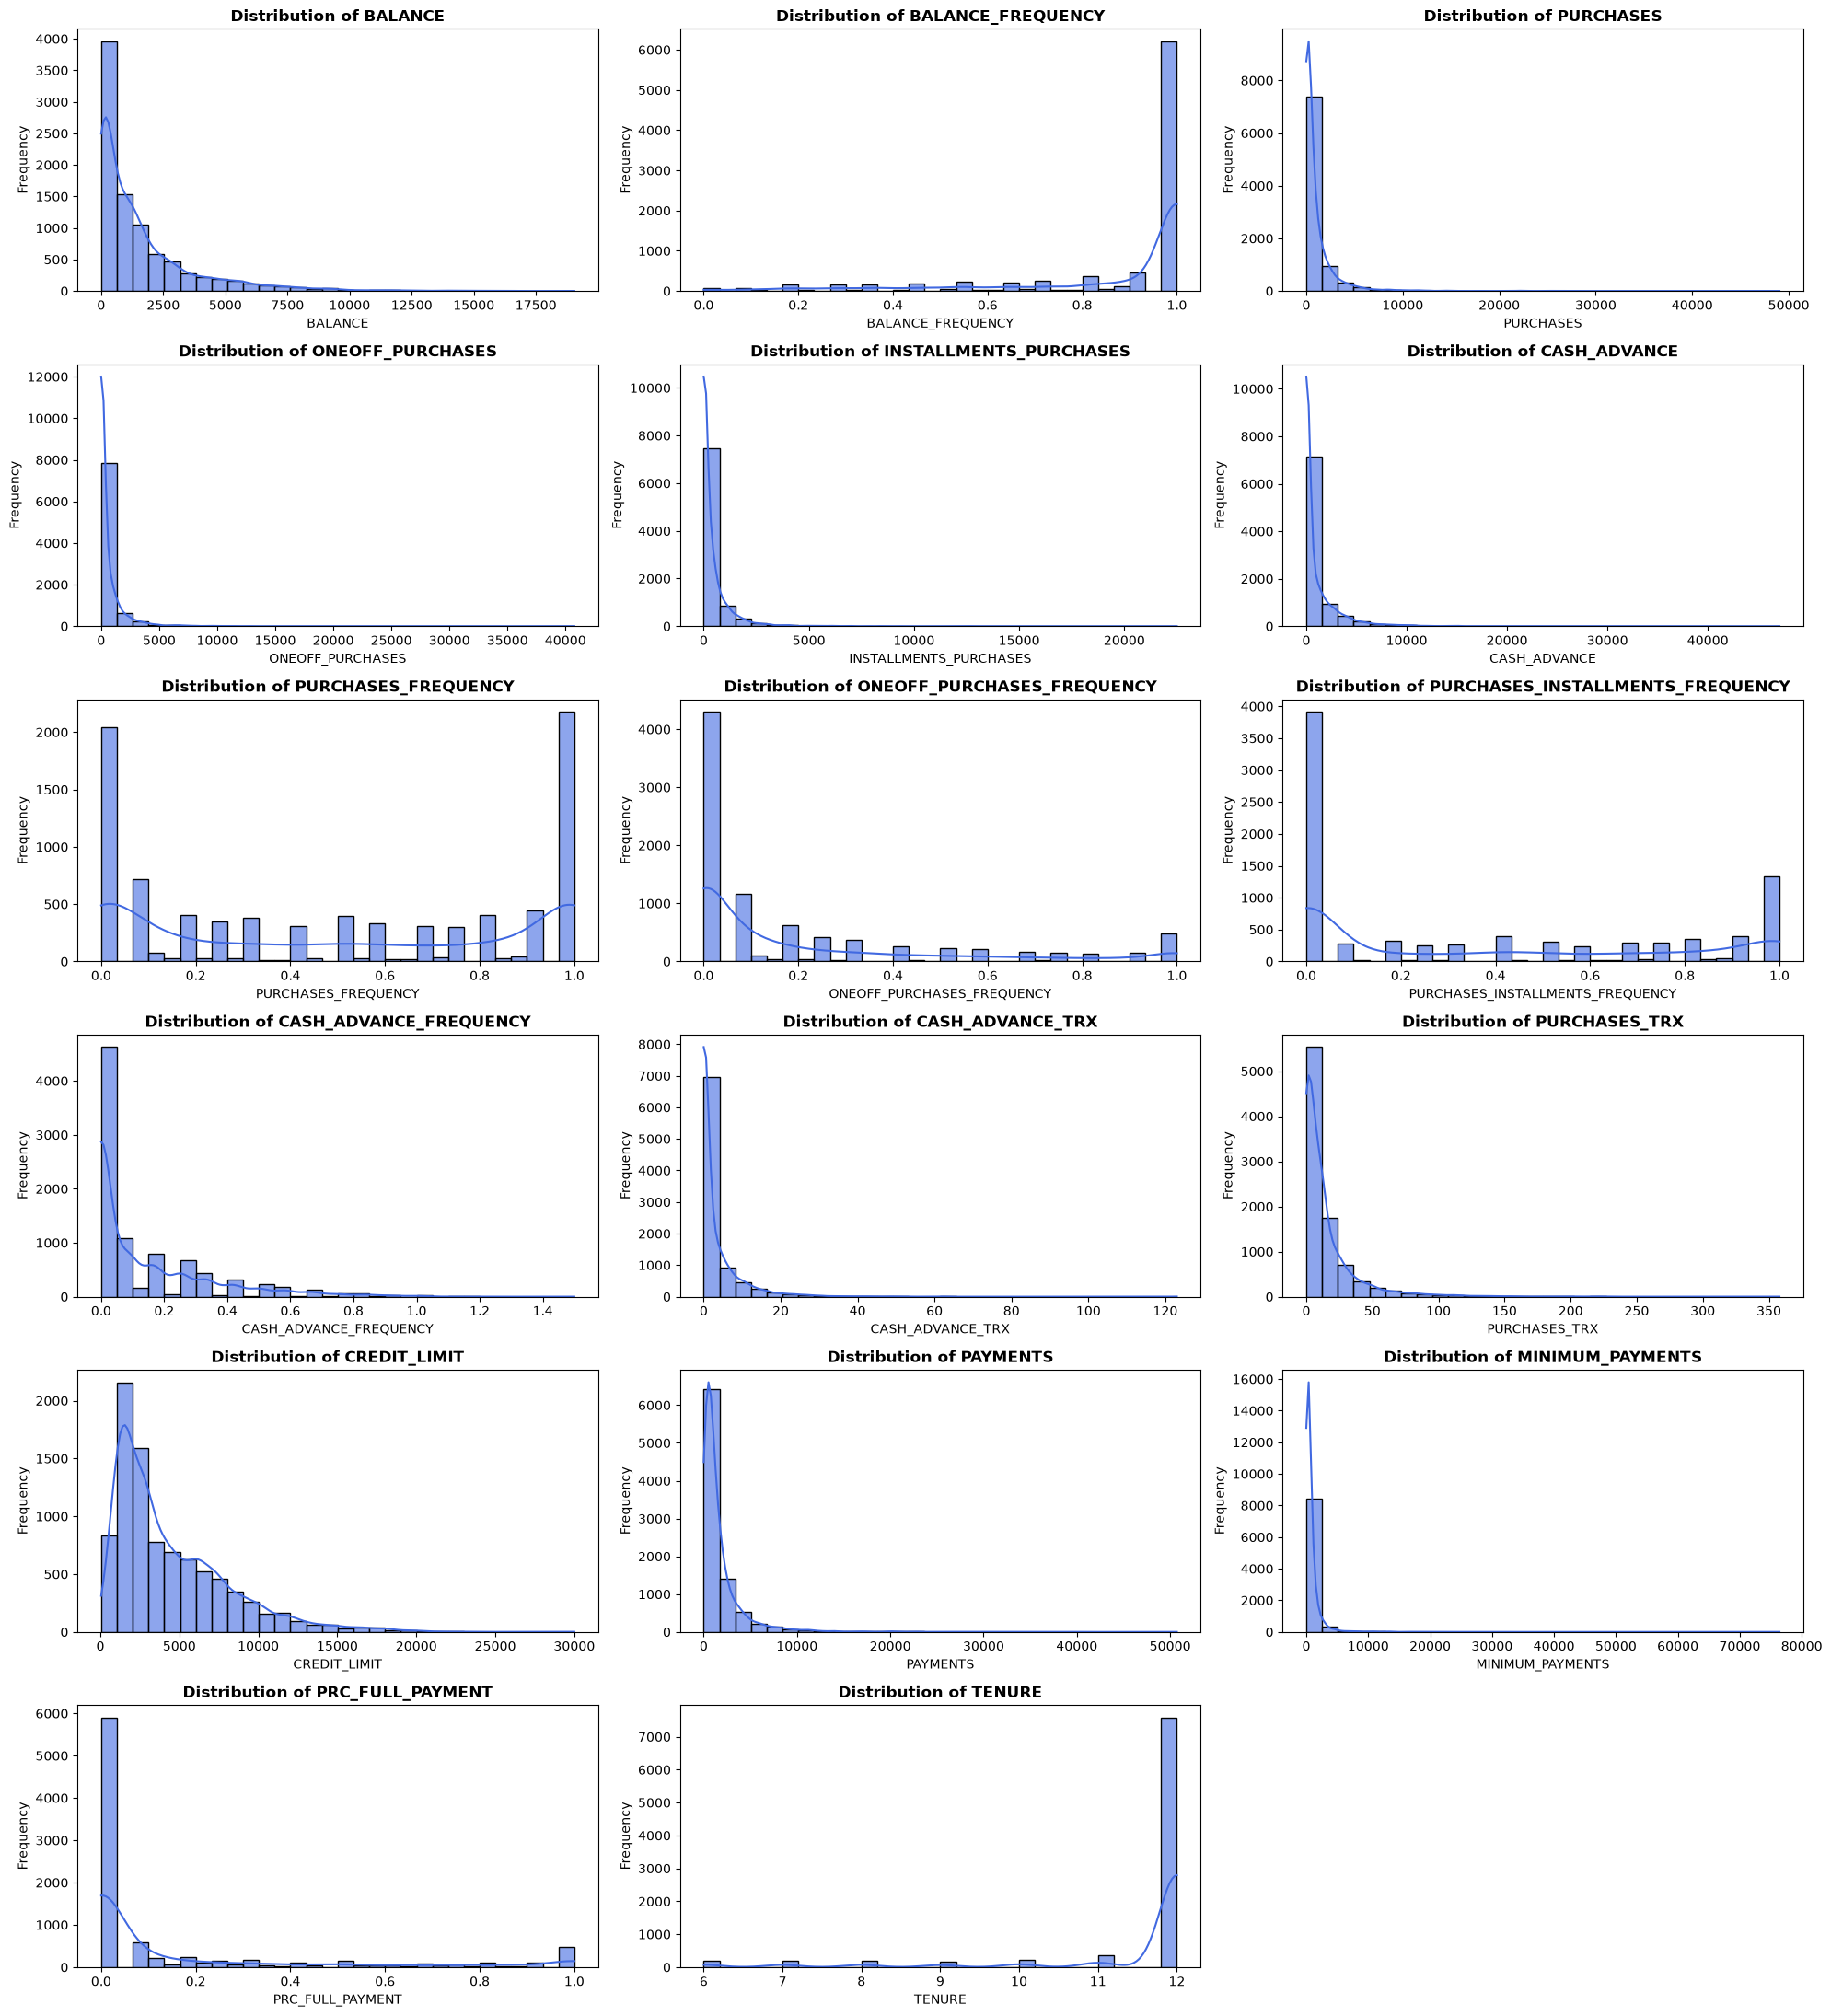

In [13]:
# Distribution plots (Histogram + KDE) for all numerical features
plt.figure(figsize=(20, 22))
cols = df.columns

for i, col in enumerate(cols, 1):
    plt.subplot(6, 3, i)
    sns.histplot(df[col], kde=True, bins=30, color='royalblue', edgecolor='black', alpha=0.6)
    plt.title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Frequency', fontsize=10)

plt.tight_layout()
plt.show()

### 2. Box Plots for Outlier Detection

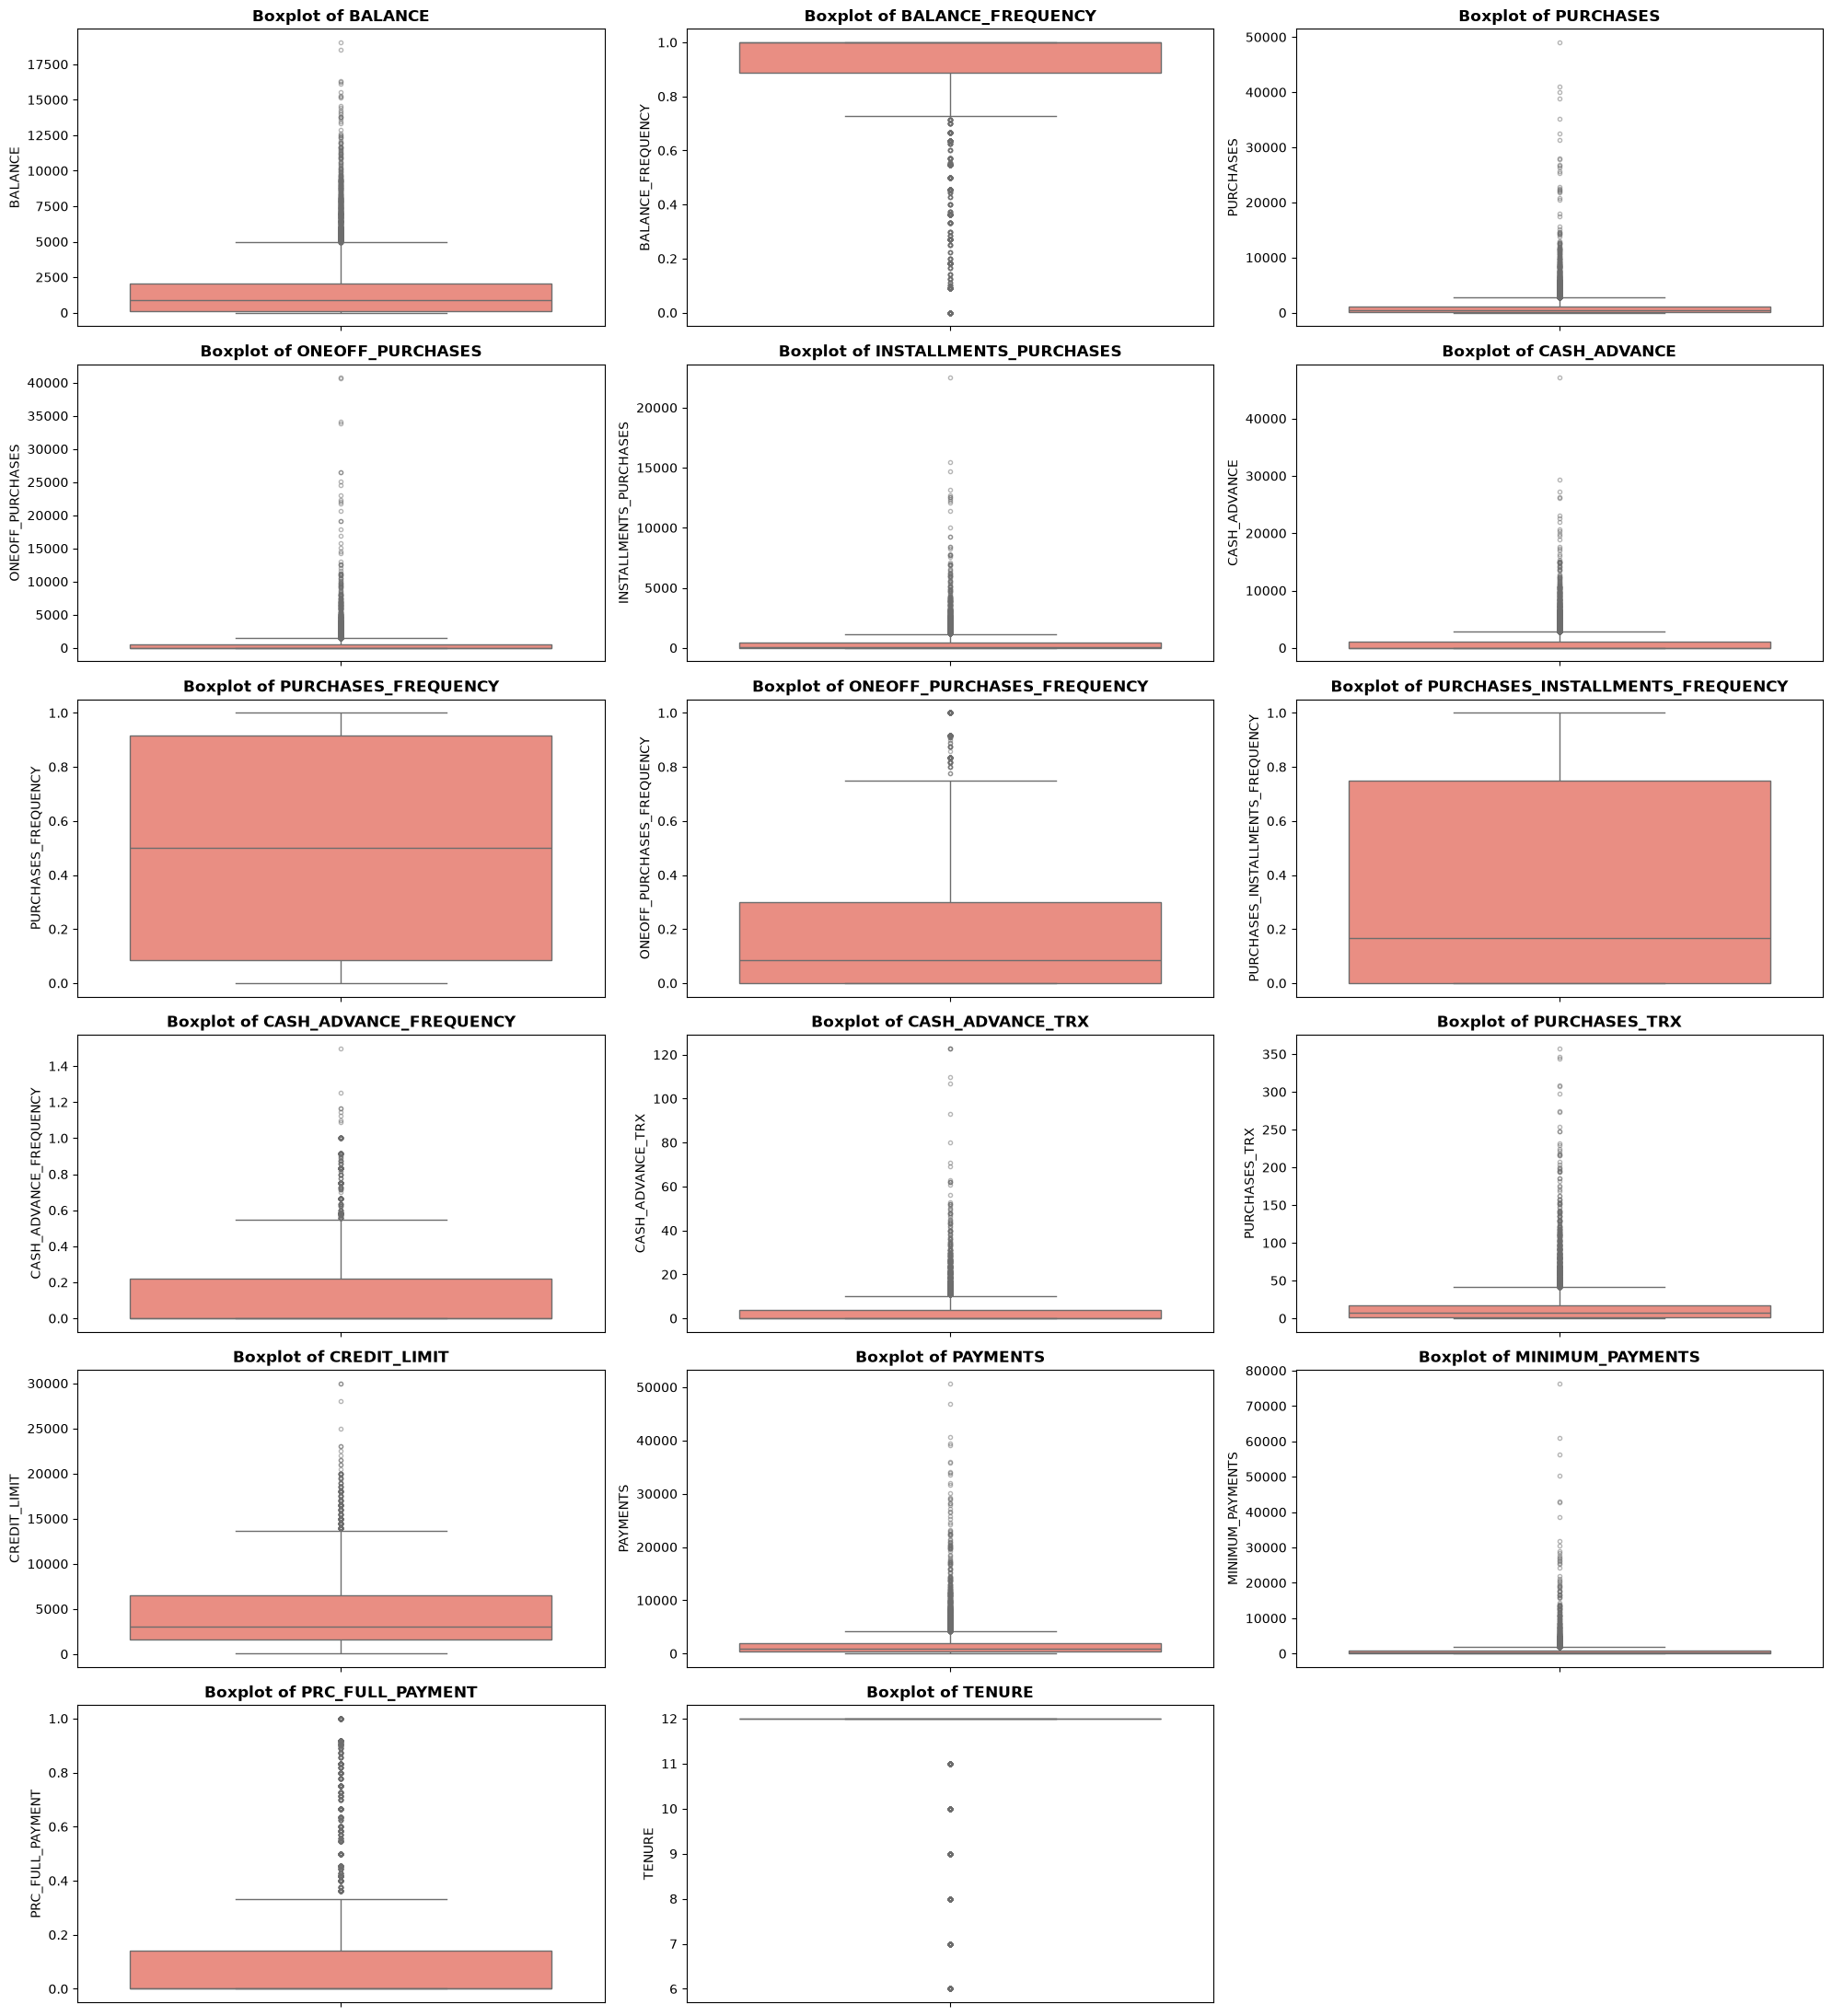

In [14]:
# Box plots to identify outliers and IQR spread for each feature
plt.figure(figsize=(20, 22))

for i, col in enumerate(cols, 1):
    plt.subplot(6, 3, i)
    sns.boxplot(y=df[col], color='salmon', flierprops=dict(marker='o', markersize=3, alpha=0.5))
    plt.title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    plt.ylabel(col, fontsize=10)

plt.tight_layout()
plt.show()

### 3. Skewness Summary

In [15]:
# Calculate and display skewness for each column
skewness_df = pd.DataFrame({
    'Feature': cols,
    'Skewness': [df[col].skew() for col in cols]
}).sort_values(by='Skewness', ascending=False).reset_index(drop=True)

skewness_df

,Feature,Skewness
0,MINIMUM_PAYMENTS,13.866771
1,ONEOFF_PURCHASES,10.044622
2,PURCHASES,8.143969
3,INSTALLMENTS_PURCHASES,7.298823
4,PAYMENTS,5.907465
5,CASH_ADVANCE_TRX,5.720976
6,CASH_ADVANCE,5.166323
7,PURCHASES_TRX,4.630493
8,BALANCE,2.393270
9,PRC_FULL_PAYMENT,1.942641


## Phase 1 — EDA Completion

### Correlation Heatmap

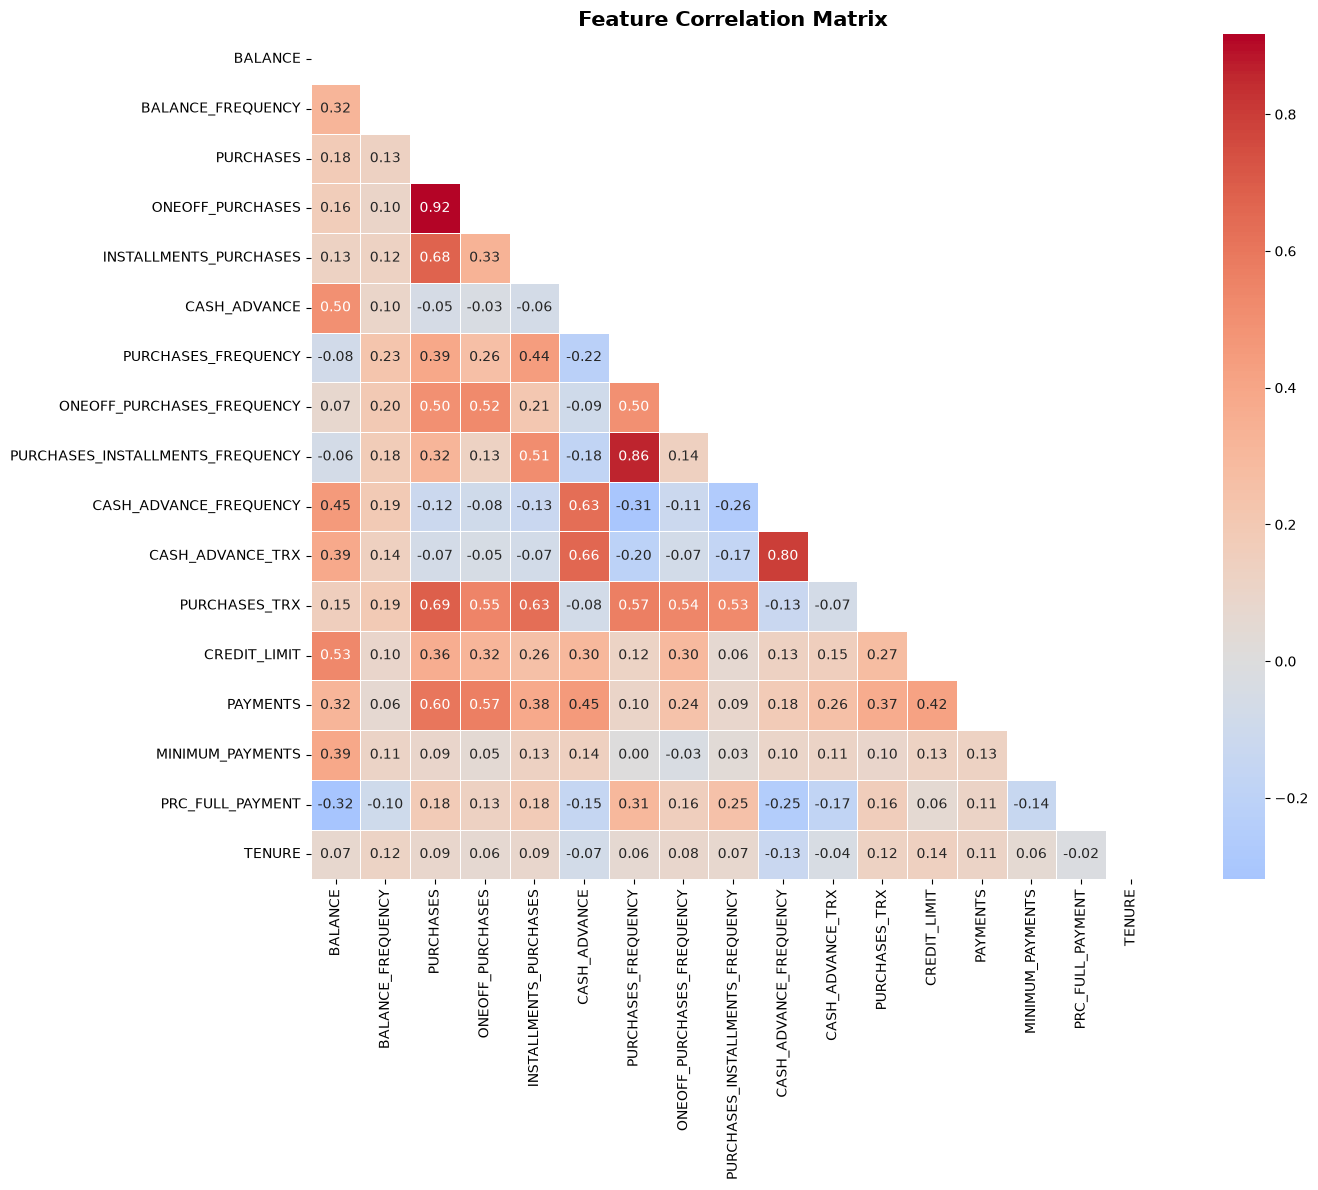

In [16]:
## Correlation Heatmap
plt.figure(figsize=(16, 12))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, square=True)
plt.title("Feature Correlation Matrix", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

### Outlier Quantification (IQR method)

In [17]:
## Outlier % per column (IQR method)
outlier_summary = {}
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    outlier_summary[col] = round(len(outliers) / len(df) * 100, 2)

outlier_df = pd.DataFrame.from_dict(outlier_summary, orient="index",
                                     columns=["Outlier %"]).sort_values("Outlier %", ascending=False)
outlier_df

,Outlier %
BALANCE_FREQUENCY,16.67
PRC_FULL_PAYMENT,16.47
TENURE,15.25
CASH_ADVANCE,11.51
ONEOFF_PURCHASES,11.32
INSTALLMENTS_PURCHASES,9.69
PURCHASES,9.03
PAYMENTS,9.03
CASH_ADVANCE_TRX,8.98
ONEOFF_PURCHASES_FREQUENCY,8.74


### Log Transform (Skewed Columns)
We apply `np.log1p()` to highly skewed monetary columns to reduce the effect of extreme outliers and bring the distributions closer to normal before scaling.

In [18]:
## Log-transform highly skewed monetary columns
skewed_cols = ["BALANCE", "PURCHASES", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES",
               "CASH_ADVANCE", "CASH_ADVANCE_TRX", "PURCHASES_TRX",
               "CREDIT_LIMIT", "PAYMENTS", "MINIMUM_PAYMENTS"]

df_transformed = df.copy()
for col in skewed_cols:
    df_transformed[col] = np.log1p(df_transformed[col])

df_transformed.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,3.735304,0.818182,4.568506,0.000000,4.568506,0.000000,0.166667,0.000000,0.083333,0.000000,0.000000,1.098612,6.908755,5.312231,4.945277,0.000000,12
1,8.071989,0.909091,0.000000,0.000000,0.000000,8.770896,0.000000,0.000000,0.000000,0.250000,1.609438,0.000000,8.853808,8.319725,6.978531,0.222222,12
2,7.822504,1.000000,6.651791,6.651791,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.564949,8.922792,6.434654,6.442994,0.000000,12
3,7.419183,0.636364,7.313220,7.313220,0.000000,5.331694,0.083333,0.083333,0.000000,0.083333,0.693147,0.693147,8.922792,0.000000,6.763082,0.000000,12
4,6.707735,1.000000,2.833213,2.833213,0.000000,0.000000,0.083333,0.083333,0.000000,0.000000,0.000000,0.693147,7.090910,6.521114,5.504483,0.000000,12


### Standard Scaling
Scale all features to mean approx 0, std approx 1 using `StandardScaler`.

In [19]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_transformed),
                          columns=df_transformed.columns)
df_scaled.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-1.205498,-0.249881,-0.113732,-0.987198,0.394362,-0.930636,-0.806649,-0.678716,-0.707409,-0.675294,-0.810038,-0.579693,-1.447095,-0.825080,-0.853732,-0.525588,0.360541
1,0.948821,0.134049,-1.680213,-0.987198,-1.087586,1.528788,-1.221928,-0.678716,-0.917090,0.573949,0.784546,-1.379434,0.925997,1.065109,0.870595,0.234159,0.360541
2,0.824885,0.517980,0.600600,1.061910,-1.087586,-0.930636,1.269742,2.673295,-0.917090,-0.675294,-0.810038,0.487735,1.010161,-0.119646,0.416426,-0.525588,0.360541
3,0.624529,-1.017743,0.827395,1.265665,-1.087586,0.564410,-1.014290,-0.399383,-0.917090,-0.258882,-0.123288,-0.874853,1.010161,-4.163779,0.687881,-0.525588,0.360541
4,0.271106,0.517980,-0.708741,-0.114417,-1.087586,-0.930636,-1.014290,-0.399383,-0.917090,-0.675294,-0.810038,-0.874853,-1.224854,-0.065306,-0.379491,-0.525588,0.360541


#### Verification: confirm mean approx 0, std approx 1

In [20]:
df_scaled.describe().round(3)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8949.000,8949.000,8949.000,8949.000,8949.000,8949.000,8949.000,8949.000,8949.000,8949.000,8949.000,8949.000,8949.000,8949.000,8949.000,8949.000,8949.000
mean,0.000,0.000,0.000,-0.000,0.000,0.000,-0.000,0.000,0.000,-0.000,0.000,0.000,0.000,-0.000,0.000,0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-3.061,-3.705,-1.680,-0.987,-1.088,-0.931,-1.222,-0.679,-0.917,-0.675,-0.810,-1.379,-5.079,-4.164,-5.032,-0.526,-4.127
25%,-0.645,0.049,-0.409,-0.987,-1.088,-0.931,-1.014,-0.679,-0.917,-0.675,-0.810,-0.875,-0.874,-0.423,-0.683,-0.526,0.361
50%,0.304,0.518,0.340,0.141,0.372,-0.931,0.024,-0.399,-0.498,-0.675,-0.810,0.134,-0.108,0.081,-0.113,-0.526,0.361
75%,0.728,0.518,0.725,0.972,0.908,1.037,1.062,0.327,0.970,0.435,0.785,0.725,0.836,0.582,0.688,-0.037,0.361
max,1.834,0.518,2.023,2.283,2.163,2.087,1.270,2.673,1.599,6.820,3.966,2.903,2.701,2.645,4.488,2.893,0.361


## Phase 2 — Dimensionality Reduction with PCA

Before clustering, we apply **Principal Component Analysis (PCA)** to reduce the 17 scaled features
to a smaller set of components that explain 95% of the total variance.

Benefits:
- Removes multicollinearity (many features are highly correlated)
- Speeds up GMM convergence
- Enables 2D visualisation of clusters via the first two principal components

Original features  : 17
PCA components kept: 10
Explained variance : 0.9588


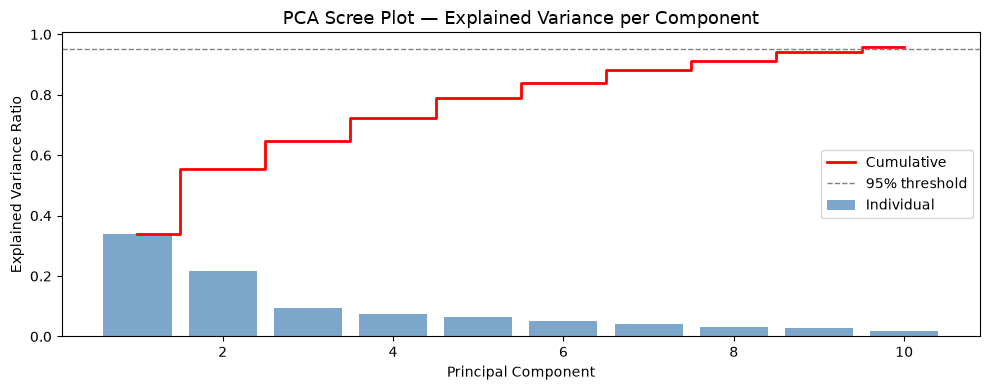

Scree plot saved → pca_scree.png


In [21]:
# ── PCA: retain components explaining 95% of variance ─────────────────────────
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(df_scaled)

print(f"Original features  : {df_scaled.shape[1]}")
print(f"PCA components kept: {pca.n_components_}")
print(f"Explained variance : {pca.explained_variance_ratio_.sum():.4f}")

# Scree plot — variance explained per component
plt.figure(figsize=(10, 4))
cumvar = pca.explained_variance_ratio_.cumsum()
plt.bar(range(1, len(cumvar)+1), pca.explained_variance_ratio_,
        color='steelblue', alpha=0.7, label='Individual')
plt.step(range(1, len(cumvar)+1), cumvar,
         where='mid', color='red', linewidth=2, label='Cumulative')
plt.axhline(0.95, color='gray', linestyle='--', linewidth=1, label='95% threshold')
plt.title('PCA Scree Plot — Explained Variance per Component', fontsize=13)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.legend()
plt.tight_layout()
plt.savefig('pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()
print("Scree plot saved → pca_scree.png")

## Phase 3 — Model Selection: Elbow Method & BIC Curve

We evaluate the optimal number of clusters (k) from **k = 2 to 10** using two complementary methods:

| Method | What it measures |
|--------|-----------------|
| **WCSS Elbow (KMeans)** | Within-Cluster Sum of Squares — standard elbow metric |
| **BIC / AIC (GMM)** | Bayesian / Akaike Information Criterion — proper metric for probabilistic models |

Both plots are used to **confirm that k = 4 is a valid and defensible choice**.

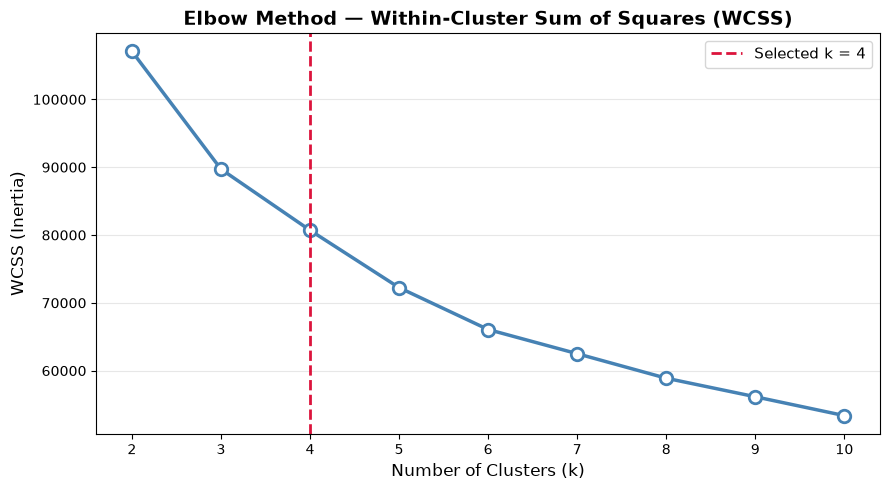

Elbow (WCSS) plot saved → elbow_wcss.png


In [22]:
# ── Elbow Method: WCSS via KMeans (k = 2 … 10) ───────────────────────────────
K_range = range(2, 11)
wcss = []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_pca)
    wcss.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(list(K_range), wcss, marker='o', color='steelblue',
         linewidth=2.5, markersize=9, markerfacecolor='white', markeredgewidth=2)
plt.axvline(x=4, color='crimson', linestyle='--', linewidth=2, label='Selected k = 4')
plt.title('Elbow Method — Within-Cluster Sum of Squares (WCSS)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('WCSS (Inertia)', fontsize=12)
plt.xticks(list(K_range))
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_wcss.png', dpi=150, bbox_inches='tight')
plt.show()
print("Elbow (WCSS) plot saved → elbow_wcss.png")

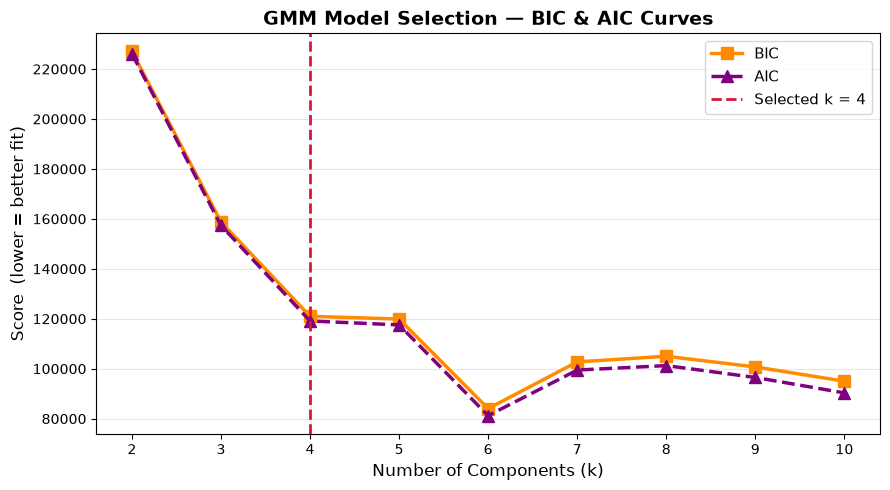

BIC / AIC plot saved → elbow_bic.png
 k          WCSS           BIC           AIC
 2 107090.253817 227087.784397 226157.776481
 3  89718.710946 158780.468101 157381.906578
 4  80701.934286 120998.609512 119131.494382
 5  72242.220687 119890.799514 117555.130777
 6  66065.869814  84036.896355  81232.674011
 7  62500.883506 102740.887086  99468.111135
 8  58885.040250 104999.739603 101258.410046
 9  56150.886071 100719.934946  96510.051782
10  53370.010487  95008.692704  90330.255933


In [23]:
# ── BIC & AIC Elbow Curve for GMM (k = 2 … 10) ───────────────────────────────
bic_scores, aic_scores = [], []

for k in K_range:
    gmm = GaussianMixture(n_components=k, covariance_type='full',
                          max_iter=300, random_state=42)
    gmm.fit(X_pca)
    bic_scores.append(gmm.bic(X_pca))
    aic_scores.append(gmm.aic(X_pca))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(K_range), bic_scores, marker='s', label='BIC',
        color='darkorange', linewidth=2.5, markersize=8)
ax.plot(list(K_range), aic_scores, marker='^', label='AIC',
        color='purple', linewidth=2.5, linestyle='--', markersize=8)
ax.axvline(x=4, color='crimson', linestyle='--', linewidth=2, label='Selected k = 4')
ax.set_title('GMM Model Selection — BIC & AIC Curves', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Components (k)', fontsize=12)
ax.set_ylabel('Score  (lower = better fit)', fontsize=12)
ax.set_xticks(list(K_range))
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_bic.png', dpi=150, bbox_inches='tight')
plt.show()
print("BIC / AIC plot saved → elbow_bic.png")

# Tabular summary
model_sel_df = pd.DataFrame({'k': list(K_range), 'WCSS': wcss,
                              'BIC': bic_scores, 'AIC': aic_scores})
print(model_sel_df.to_string(index=False))

## Phase 4 — Gaussian Mixture Model (GMM) with 4 Clusters

**Why GMM over K-Means?**
- GMM is a **probabilistic model**: each customer is assigned a soft probability of belonging to each cluster, not just a hard label.
- GMM handles **ellipsoidal cluster shapes** (`covariance_type='full'`), which is more realistic for customer behavioral data where groups naturally overlap.
- It is more robust to the heavy-tailed, skewed distributions present in this dataset.

We train with:
- `n_components = 4` — confirmed by elbow analysis above
- `covariance_type = 'full'` — each component has its own full covariance matrix
- `n_init = 10` — run 10 random initialisations, select best log-likelihood

In [24]:
# ── Train final GMM ───────────────────────────────────────────────────────────
gmm_final = GaussianMixture(
    n_components=4,
    covariance_type='full',
    max_iter=300,
    n_init=10,
    random_state=42
)
gmm_final.fit(X_pca)

# Hard cluster assignments (argmax of posterior probabilities)
cluster_labels = gmm_final.predict(X_pca)

# Soft probabilities (posterior probability per cluster per customer)
cluster_probs = gmm_final.predict_proba(X_pca)

print("GMM Converged     :", gmm_final.converged_)
print("Iterations used   :", gmm_final.n_iter_)
print(f"Final BIC         : {gmm_final.bic(X_pca):,.2f}")
print(f"Final AIC         : {gmm_final.aic(X_pca):,.2f}")
print()
dist = pd.Series(cluster_labels).value_counts().sort_index()
dist.index = [f"Cluster {i}" for i in dist.index]
print("Cluster distribution:")
print(dist.to_string())

GMM Converged     : True
Iterations used   : 29
Final BIC         : 120,998.61
Final AIC         : 119,131.49

Cluster distribution:
Cluster 0    1856
Cluster 1    2535
Cluster 2    2763
Cluster 3    1795


## Phase 5 — Cluster Validation

We use three complementary metrics to assess cluster quality:

| Metric | What it measures | Target |
|--------|-----------------|--------|
| **Silhouette Score** | Average inter- vs intra-cluster distance (−1 to 1) | > 0.20 |
| **Davies-Bouldin Index** | Ratio of within-cluster scatter to between-cluster separation | < 1.5 |
| **BIC (GMM)** | Penalised log-likelihood — already minimised during model selection | — |

In [25]:
sil   = silhouette_score(X_pca, cluster_labels)
db    = davies_bouldin_score(X_pca, cluster_labels)
bic_4 = gmm_final.bic(X_pca)

print("=" * 50)
print("  GMM Cluster Validation Metrics")
print("=" * 50)
print(f"  Silhouette Score      : {sil:.4f}  (higher → better)")
print(f"  Davies-Bouldin Index  : {db:.4f}  (lower  → better)")
print(f"  BIC (k=4)             : {bic_4:,.2f}")
print("=" * 50)

# Interpret silhouette
if sil >= 0.5:
    interp = "Strong cluster structure"
elif sil >= 0.25:
    interp = "Reasonable cluster structure"
else:
    interp = "Weak structure — clusters may overlap (common in real-world behavioral data)"
print(f"  Interpretation        : {interp}")

  GMM Cluster Validation Metrics
  Silhouette Score      : 0.1428  (higher → better)
  Davies-Bouldin Index  : 2.5200  (lower  → better)
  BIC (k=4)             : 120,998.61
  Interpretation        : Weak structure — clusters may overlap (common in real-world behavioral data)


## Phase 6 — Cluster Profiling & Business Persona Mapping

We attach cluster labels to the **original (untransformed) feature values** for interpretable profiling.
Each cluster's mean feature values reveal distinct behavioural patterns,
which are then mapped to actionable **business personas**.

In [26]:
# ── Attach cluster labels to original df ─────────────────────────────────────
df_profiling = df.copy()
df_profiling['Cluster'] = cluster_labels

# Mean of original (non-scaled) feature values per cluster
cluster_profile = df_profiling.groupby('Cluster').mean().round(2)

print("Cluster Feature Profiles (mean original values):")
print(cluster_profile.T.to_string())

Cluster Feature Profiles (mean original values):
Cluster                                 0        1        2        3
BALANCE                           2322.47   245.15  2698.79   898.78
BALANCE_FREQUENCY                    0.93     0.81     1.00     0.74
PURCHASES                            0.00  1406.20  1335.22   960.87
ONEOFF_PURCHASES                     0.00   790.32   803.01   601.75
INSTALLMENTS_PURCHASES               0.00   616.44   532.43   359.49
CASH_ADVANCE                      2035.64     0.00  1071.65  1126.23
PURCHASES_FREQUENCY                  0.00     0.69     0.62     0.51
ONEOFF_PURCHASES_FREQUENCY           0.00     0.27     0.29     0.19
PURCHASES_INSTALLMENTS_FREQUENCY     0.00     0.54     0.46     0.36
CASH_ADVANCE_FREQUENCY               0.28     0.00     0.15     0.15
CASH_ADVANCE_TRX                     6.50     0.00     3.82     3.60
PURCHASES_TRX                        0.00    20.47    21.40    11.51
CREDIT_LIMIT                      4102.03  4672.01  50

In [27]:
# ── Business Persona Mapping (manually refined from cluster profiles) ─────────
#
# Cluster 0: CASH_ADVANCE=2035 (highest), PURCHASES=0 (zero), BALANCE=2322
#            -> "Revolvers (Cash Dependent)" — rely on cash advances, never purchase
#
# Cluster 1: PURCHASES=1406 (highest), PRC_FULL_PAYMENT=0.38 (highest), CASH_ADVANCE=0
#            -> "Transactors (Full Payers)" — active purchasers who pay bills in full
#
# Cluster 2: CREDIT_LIMIT=5004 (highest), BALANCE=2698 (highest), PURCHASES=1335
#            -> "High-Value Customers" — premium segment, high limits & high spend
#
# Cluster 3: Lowest CREDIT_LIMIT(3864), lowest TENURE(10.2), moderate on all metrics
#            -> "Low Engagement / Growth Opportunity" — newer, underutilised accounts

persona_map = {
    0: "Revolvers (Cash Dependent)",
    1: "Transactors (Full Payers)",
    2: "High-Value Customers",
    3: "Low Engagement / Growth Opportunity"
}

print("Business Persona Labels:")
for k, v in persona_map.items():
    print(f"  Cluster {k} -> {v}")

df_profiling['Segment'] = df_profiling['Cluster'].map(persona_map)
print()
print("Segment sizes:")
print(df_profiling['Segment'].value_counts().to_string())

Business Persona Labels:
  Cluster 0 -> Revolvers (Cash Dependent)
  Cluster 1 -> Transactors (Full Payers)
  Cluster 2 -> High-Value Customers
  Cluster 3 -> Low Engagement / Growth Opportunity

Segment sizes:
Segment
High-Value Customers                   2763
Transactors (Full Payers)              2535
Revolvers (Cash Dependent)             1856
Low Engagement / Growth Opportunity    1795


In [28]:
# ── Cluster profile summary table ─────────────────────────────────────────────
summary_cols = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE',
                'PRC_FULL_PAYMENT', 'CREDIT_LIMIT',
                'PURCHASES_FREQUENCY', 'MINIMUM_PAYMENTS']

profile_summary = cluster_profile[summary_cols].copy()
profile_summary.index = [f"Cluster {i} — {persona_map[i]}" for i in range(4)]

print("\nCluster Business Profile Summary")
print("=" * 80)
print(profile_summary.T.to_string())


Cluster Business Profile Summary
                     Cluster 0 — Revolvers (Cash Dependent)  Cluster 1 — Transactors (Full Payers)  Cluster 2 — High-Value Customers  Cluster 3 — Low Engagement / Growth Opportunity
BALANCE                                             2322.47                                 245.15                           2698.79                                           898.78
PURCHASES                                              0.00                                1406.20                           1335.22                                           960.87
CASH_ADVANCE                                        2035.64                                   0.00                           1071.65                                          1126.23
PRC_FULL_PAYMENT                                       0.02                                   0.38                              0.01                                             0.19
CREDIT_LIMIT                                        4102

## Phase 7 — Cluster Visualizations

### 7.1  2D PCA Scatter Plot
Customers projected onto the first two principal components,
coloured by their assigned GMM cluster / business segment.

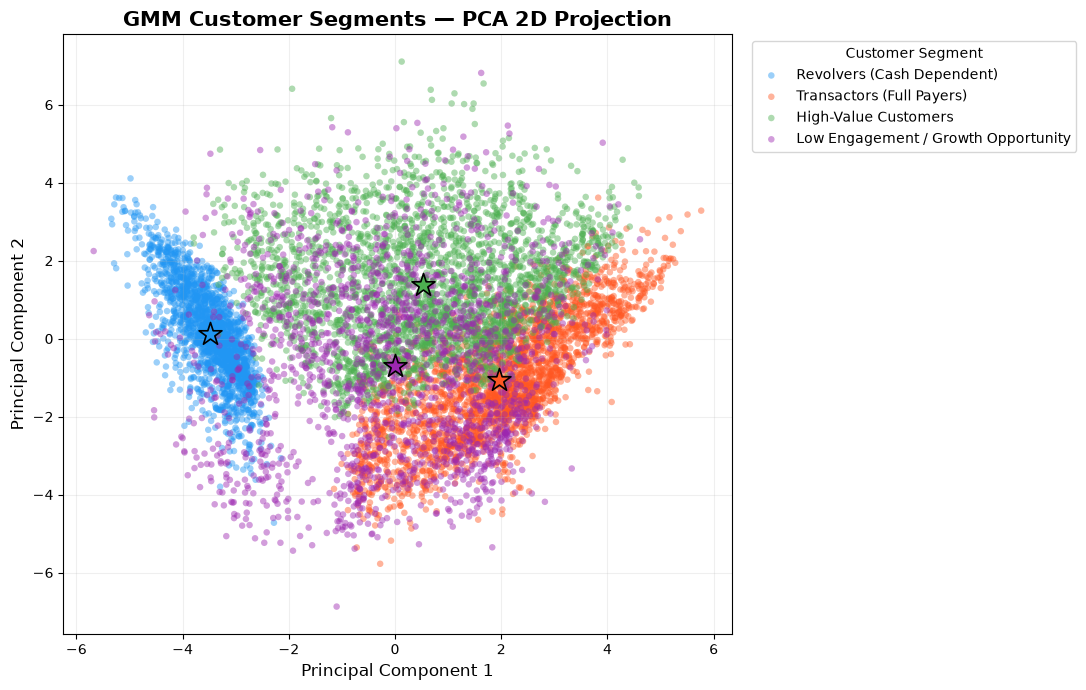

Cluster scatter saved → gmm_clusters_pca.png


In [29]:
# ── 2D PCA Scatter — PC1 vs PC2 ──────────────────────────────────────────────
palette = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']
segment_labels = [persona_map[i] for i in range(4)]

plt.figure(figsize=(11, 7))
for cid in range(4):
    mask = cluster_labels == cid
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=palette[cid], label=segment_labels[cid],
                alpha=0.45, s=22, edgecolors='none')

# Mark cluster centroids (GMM means projected to 2D)
means_2d = gmm_final.means_[:, :2]
for cid in range(4):
    plt.scatter(means_2d[cid, 0], means_2d[cid, 1],
                c=palette[cid], marker='*', s=300,
                edgecolors='black', linewidths=1.2, zorder=5)

plt.title('GMM Customer Segments — PCA 2D Projection', fontsize=15, fontweight='bold')
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Customer Segment', bbox_to_anchor=(1.02, 1),
           loc='upper left', fontsize=10)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('gmm_clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cluster scatter saved → gmm_clusters_pca.png")

### 7.2  Cluster Feature Profile Heatmap
Normalized mean values of key features per cluster —
darker = higher relative value within that feature.

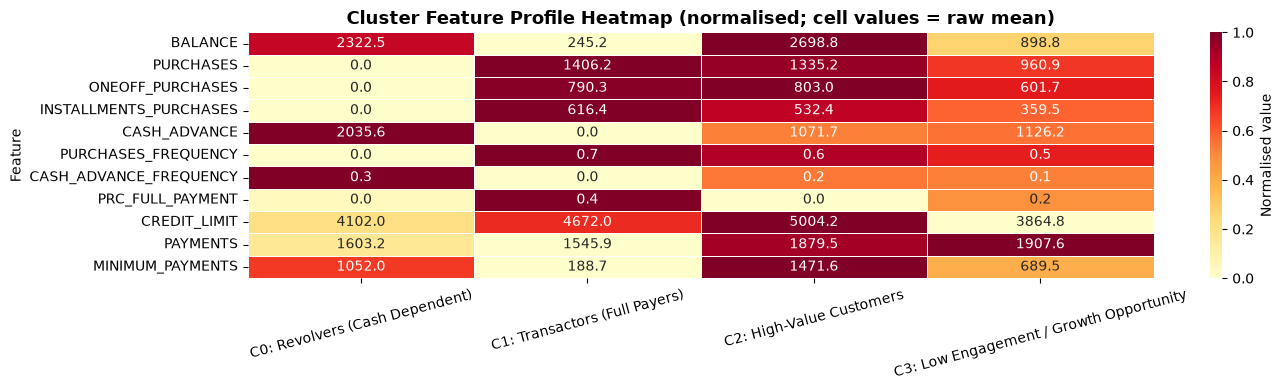

Profile heatmap saved → gmm_profile_heatmap.png


In [30]:
# ── Cluster Profile Heatmap ───────────────────────────────────────────────────
heat_cols = ['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES',
             'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
             'PURCHASES_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
             'PRC_FULL_PAYMENT', 'CREDIT_LIMIT',
             'PAYMENTS', 'MINIMUM_PAYMENTS']

profile_heat = df_profiling.groupby('Cluster')[heat_cols].mean()
profile_norm = (profile_heat - profile_heat.min()) /                (profile_heat.max() - profile_heat.min() + 1e-9)
profile_norm.index = [f"C{i}: {persona_map[i]}" for i in range(4)]

plt.figure(figsize=(14, 4))
sns.heatmap(profile_norm.T, annot=profile_heat.T.round(1),
            fmt='.1f', cmap='YlOrRd',
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'Normalised value'})
plt.title('Cluster Feature Profile Heatmap (normalised; cell values = raw mean)',
          fontsize=13, fontweight='bold')
plt.ylabel('Feature')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('gmm_profile_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Profile heatmap saved → gmm_profile_heatmap.png")

### 7.3  Segment Size Bar Chart

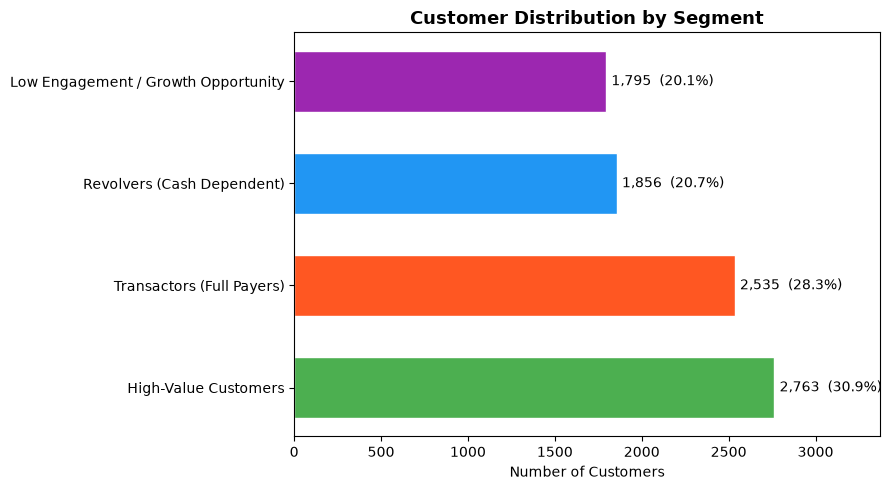

Segment size chart saved → gmm_segment_sizes.png


In [31]:
# ── Segment size bar chart ────────────────────────────────────────────────────
seg_counts = df_profiling['Segment'].value_counts()
colors_bar  = [palette[list(persona_map.values()).index(s)] for s in seg_counts.index]

plt.figure(figsize=(9, 5))
bars = plt.barh(seg_counts.index, seg_counts.values,
                color=colors_bar, edgecolor='white', height=0.6)
for bar, val in zip(bars, seg_counts.values):
    plt.text(val + 30, bar.get_y() + bar.get_height()/2,
             f'{val:,}  ({val/len(df_profiling)*100:.1f}%)',
             va='center', fontsize=10)
plt.title('Customer Distribution by Segment', fontsize=13, fontweight='bold')
plt.xlabel('Number of Customers')
plt.xlim(0, seg_counts.max() * 1.22)
plt.tight_layout()
plt.savefig('gmm_segment_sizes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Segment size chart saved → gmm_segment_sizes.png")

## Phase 8 — Final Summary & Output

Export the customer-level dataframe with assigned `Cluster` and `Segment` columns
for downstream use (e.g., application UI, Excel upload feature).

In [32]:
# ── Export segmented customer data ────────────────────────────────────────────
df_output = df_profiling.copy()
df_output.insert(0, 'CUST_ID', pd.read_csv('Customer Data.csv')['CUST_ID']
                                  .dropna().reset_index(drop=True)
                                  .iloc[:len(df_output)].values)

df_output.to_csv('customer_segments_gmm.csv', index=False)
print(f"Segmented data exported → customer_segments_gmm.csv")
print(f"Shape: {df_output.shape}")
print()
print("=" * 55)
print("  GMM Clustering — Final Report")
print("=" * 55)
print(f"  Model            : Gaussian Mixture Model")
print(f"  Clusters (k)     : 4")
print(f"  Covariance type  : full")
print(f"  PCA components   : {pca.n_components_}")
print(f"  Silhouette Score : {sil:.4f}")
print(f"  Davies-Bouldin   : {db:.4f}")
print(f"  BIC              : {gmm_final.bic(X_pca):,.2f}")
print("=" * 55)
print("  Segment Breakdown:")
for seg, cnt in df_profiling['Segment'].value_counts().items():
    print(f"    {seg:<35} : {cnt:>5,} customers  ({cnt/len(df_profiling)*100:.1f}%)")
print("=" * 55)

Segmented data exported → customer_segments_gmm.csv
Shape: (8949, 20)

  GMM Clustering — Final Report
  Model            : Gaussian Mixture Model
  Clusters (k)     : 4
  Covariance type  : full
  PCA components   : 10
  Silhouette Score : 0.1428
  Davies-Bouldin   : 2.5200
  BIC              : 120,998.61
  Segment Breakdown:
    High-Value Customers                : 2,763 customers  (30.9%)
    Transactors (Full Payers)           : 2,535 customers  (28.3%)
    Revolvers (Cash Dependent)          : 1,856 customers  (20.7%)
    Low Engagement / Growth Opportunity : 1,795 customers  (20.1%)


In [33]:
joblib.dump(gmm_final, "gmm_model.pkl")

['gmm_model.pkl']

In [34]:
# Train-test split for predicting the generated GMM segment labels
x = df_output.drop(['CUST_ID', 'Cluster', 'Segment', 'Confidence'], axis=1, errors='ignore')
y = df_output['Segment']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

x_train

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
4004,99.029726,1.000000,1496.87,429.27,1067.60,0.000000,0.916667,0.333333,0.833333,0.000000,0,48,5000.0,1760.086698,164.907900,0.416667,12
8005,196.626598,1.000000,2017.11,1056.66,960.45,0.000000,1.000000,1.000000,0.750000,0.000000,0,28,7500.0,1425.513446,153.957216,1.000000,12
3721,3337.178486,1.000000,883.39,106.09,777.30,5338.547155,0.833333,0.166667,0.750000,0.416667,12,20,6000.0,4039.075325,1344.980722,0.083333,12
799,26.680023,0.545455,520.50,0.00,520.50,0.000000,0.500000,0.000000,0.500000,0.000000,0,15,4000.0,551.370293,88.814191,0.454545,12
5603,59.325240,1.000000,527.63,0.00,527.63,0.000000,1.000000,0.000000,0.900000,0.000000,0,11,1000.0,435.994202,158.158755,0.875000,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3333,1502.292117,1.000000,0.00,0.00,0.00,188.762242,0.000000,0.000000,0.000000,0.083333,1,0,4600.0,544.978537,368.962968,0.000000,12
6668,20.502046,0.818182,53.36,0.00,53.36,0.000000,0.250000,0.000000,0.166667,0.000000,0,3,2500.0,88.897909,144.512685,0.000000,12
1716,269.911748,1.000000,1348.44,1259.44,89.00,298.491305,1.000000,1.000000,0.416667,0.250000,4,44,500.0,1258.023851,250.283276,0.000000,12
1163,7370.257624,1.000000,0.00,0.00,0.00,1194.995991,0.000000,0.000000,0.000000,0.666667,8,0,7500.0,2278.457657,2202.491764,0.000000,12


In [35]:
x_test

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
3259,6246.069586,1.000000,0.00,0.00,0.00,5518.298040,0.000000,0.000000,0.000000,0.166667,4,0,10000.0,1462.274274,2206.014199,0.000000,12
8488,410.466315,0.545455,826.00,116.00,710.00,750.502530,0.909091,0.181818,0.818182,0.090909,2,15,1000.0,1750.067404,483.936762,0.125000,11
5977,538.468542,1.000000,0.00,0.00,0.00,1766.880842,0.000000,0.000000,0.000000,0.250000,8,0,8000.0,6313.310688,357.783692,0.100000,12
4767,1063.614099,1.000000,0.00,0.00,0.00,196.616463,0.000000,0.000000,0.000000,0.083333,1,0,1200.0,206.505212,316.230814,0.000000,12
6732,1647.860393,1.000000,1510.00,0.00,1510.00,2993.136369,0.833333,0.000000,0.833333,0.166667,3,11,3500.0,3927.022653,1464.023513,0.083333,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6409,46.103924,0.818182,443.25,443.25,0.00,0.000000,0.250000,0.250000,0.000000,0.000000,0,3,6500.0,417.350534,93.536782,0.000000,12
2797,58.142915,0.400000,0.00,0.00,0.00,151.730077,0.000000,0.000000,0.000000,0.100000,1,0,1200.0,79.965023,136.403124,0.000000,10
5674,391.673369,1.000000,1944.64,1333.38,611.26,0.000000,0.833333,0.666667,0.583333,0.000000,0,29,6000.0,2218.376164,211.587611,0.083333,12
8137,31.997904,0.333333,0.00,0.00,0.00,136.755929,0.000000,0.000000,0.000000,0.166667,1,0,500.0,0.000000,864.304943,0.000000,6


In [36]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score


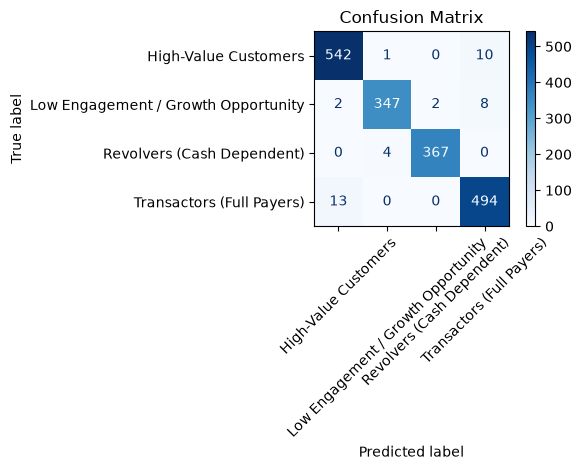

Accuracy: 0.9777


In [37]:
# Train a simple classifier to predict the GMM segment labels
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(x_train, y_train)

# Predict on test data
y_pred = rf_model.predict(x_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

In [38]:
print(classification_report(y_test, y_pred, target_names=rf_model.classes_))

                                     precision    recall  f1-score   support

               High-Value Customers       0.97      0.98      0.98       553
Low Engagement / Growth Opportunity       0.99      0.97      0.98       359
         Revolvers (Cash Dependent)       0.99      0.99      0.99       371
          Transactors (Full Payers)       0.96      0.97      0.97       507

                           accuracy                           0.98      1790
                          macro avg       0.98      0.98      0.98      1790
                       weighted avg       0.98      0.98      0.98      1790

